# Analiza ankiety UX: Gmail vs Outlook
Porównanie interakcji użytkowników na platformach Gmail i Outlook.

## 1. Ładowanie danych z Supabase

In [1]:
from dotenv import load_dotenv
from pathlib import Path
import os

env_path = Path.cwd().parent / '.env'
load_dotenv(env_path)
url = os.getenv('SUPABASE_URL')
key = os.getenv('SUPABASE_ANON_KEY')

print(f'URL: {url}')
print(f'Key loaded: {bool(key)}')

URL: https://safjbkbguskradqrpqdr.supabase.co
Key loaded: True


In [2]:
from supabase import create_client

supabase = create_client(url, key)
response = supabase.table('survey_responses').select('*').execute()
data = response.data
print(f'Pobrano {len(data)} odpowiedzi')

Pobrano 23 odpowiedzi


## 2. Przegląd danych

In [3]:
import pandas as pd

df = pd.DataFrame(data)
df['created_at'] = pd.to_datetime(df['created_at'])

print(f'Liczba odpowiedzi: {len(df)}')
print(f'Kolumny: {list(df.columns)}')
print(f'\nPierwsze 5 wierszy:')
df.head()

Liczba odpowiedzi: 23
Kolumny: ['id', 'created_at', 'participant_name', 'experience_level', 'overall_preference', 'overall_comment', 'q1_gmail', 'q1_outlook', 'q2_gmail', 'q2_outlook', 'q3_gmail', 'q3_outlook', 'q4_gmail', 'q4_outlook', 'q5_gmail', 'q5_outlook', 'q6_gmail', 'q6_outlook', 'q7_gmail', 'q7_outlook', 'q8_gmail', 'q8_outlook']

Pierwsze 5 wierszy:


,id,created_at,participant_name,experience_level,overall_preference,overall_comment,q1_gmail,q1_outlook,q2_gmail,q2_outlook,...,q4_gmail,q4_outlook,q5_gmail,q5_outlook,q6_gmail,q6_outlook,q7_gmail,q7_outlook,q8_gmail,q8_outlook
0,1bfa27df-ceb9-4515-a8c1-deafade4b625,2026-04-19 17:26:37.835460+00:00,test_user,brak,gmail,Test insert z pliku.,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,64706e26-990e-4a80-8285-ceaa2c8b14d0,2026-05-20 21:25:51.754481+00:00,123,brak,gmail,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,5.0,3.0,1.0,1.0
2,fe425d6a-7fc2-49c3-97be-718e9eeea954,2026-05-20 21:49:20.965114+00:00,asd,brak,remis,NaN,4.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,b15859c9-9c74-4f6c-8afb-f3562b2da666,2026-05-21 15:58:19.710747+00:00,kasia_92,sredniozaawansowany,outlook,,6.0,7.0,5.0,9.0,...,6.0,8.0,6.0,7.0,5.0,7.0,6.0,9.0,4.0,7.0
4,fac80617-ae5f-44c3-83e9-63e5a0b7dd0d,2026-05-21 15:58:19.851469+00:00,piotrM,poczatkujacy,gmail,Outlook męczy mnie wolnym działaniem.,9.0,7.0,NaN,NaN,...,9.0,5.0,5.0,5.0,6.0,3.0,6.0,4.0,8.0,6.0


In [4]:
# Liczba wypełnionych ocen dla każdego pytania
questions = [f'q{i}' for i in range(1, 9)]
filled = {q: df[f'{q}_gmail'].notna().sum() for q in questions}
pd.Series(filled, name='Liczba odpowiedzi').to_frame()

,Liczba odpowiedzi
q1,21
q2,17
q3,17
q4,19
q5,20
q6,17
q7,20
q8,20


## 3. Średnie ocen Gmail vs Outlook (wykresy słupkowe)

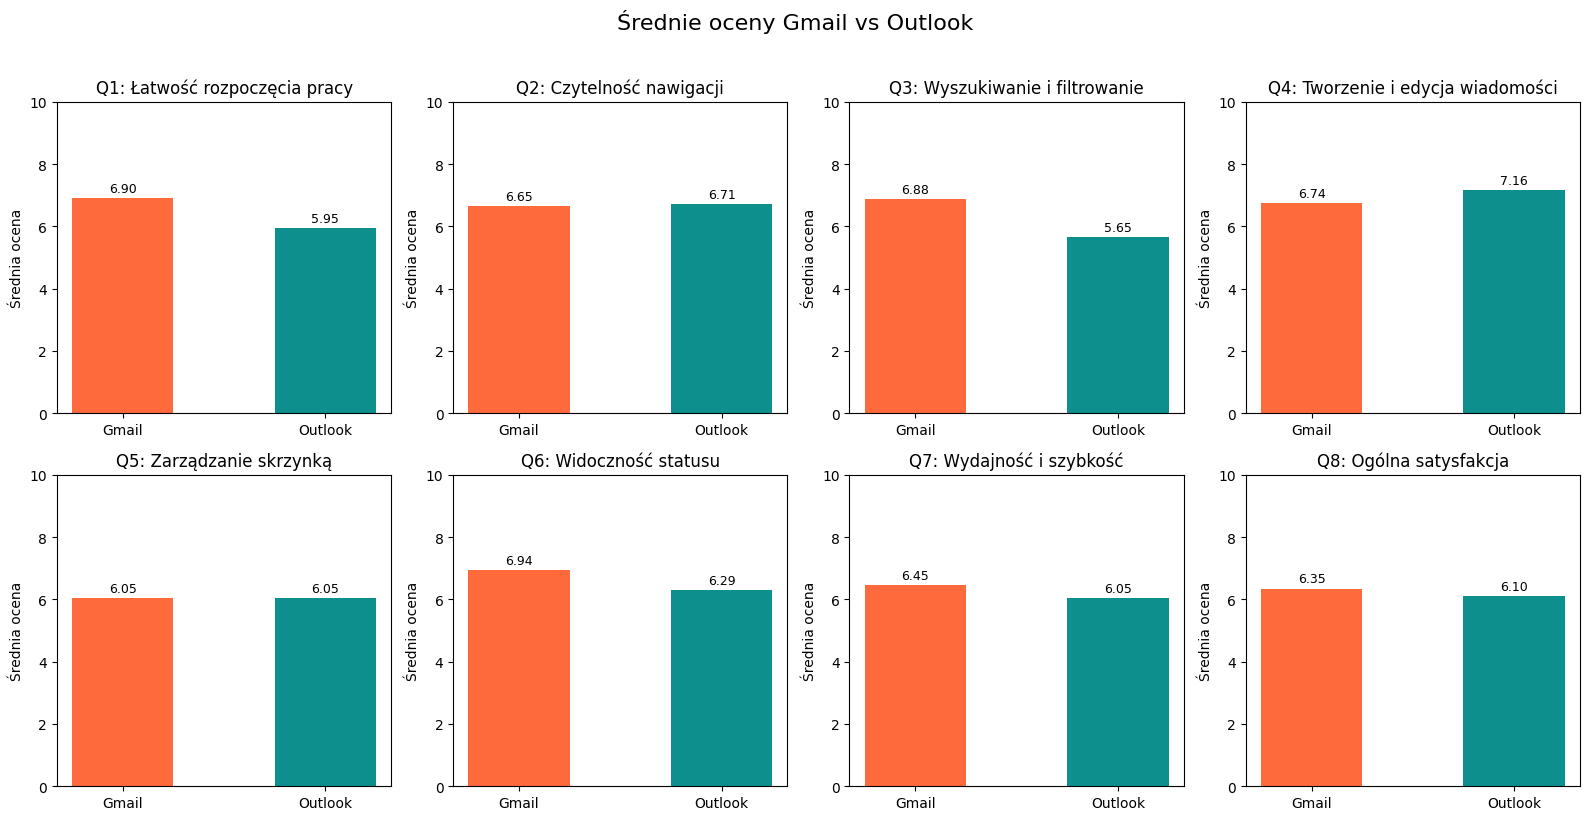

In [5]:
import matplotlib.pyplot as plt
import numpy as np

titles = {
    'q1': 'Łatwość rozpoczęcia pracy',
    'q2': 'Czytelność nawigacji',
    'q3': 'Wyszukiwanie i filtrowanie',
    'q4': 'Tworzenie i edycja wiadomości',
    'q5': 'Zarządzanie skrzynką',
    'q6': 'Widoczność statusu',
    'q7': 'Wydajność i szybkość',
    'q8': 'Ogólna satysfakcja'
}

means_gmail = [df[f'{q}_gmail'].mean() for q in questions]
means_outlook = [df[f'{q}_outlook'].mean() for q in questions]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Średnie oceny Gmail vs Outlook', fontsize=16, y=1.02)

for i, q in enumerate(questions):
    ax = axes[i // 4][i % 4]
    x = np.arange(2)
    bars = ax.bar(x, [means_gmail[i], means_outlook[i]],
                  color=['#ff6a3d', '#0d8f8d'], width=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(['Gmail', 'Outlook'])
    ax.set_ylim(0, 10)
    ax.set_ylabel('Średnia ocena')
    ax.set_title(f'Q{i+1}: {titles[q]}')
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.1,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

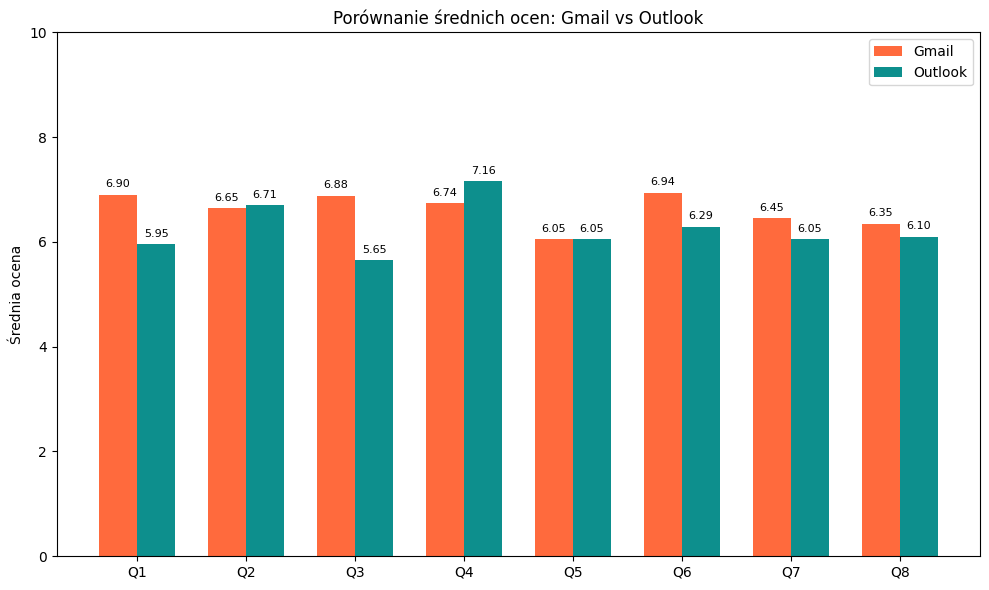

In [6]:
# Zbiorczy wykres porównawczy
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(questions))
w = 0.35

bars1 = ax.bar(x - w/2, means_gmail, w, label='Gmail', color='#ff6a3d')
bars2 = ax.bar(x + w/2, means_outlook, w, label='Outlook', color='#0d8f8d')

ax.set_xticks(x)
ax.set_xticklabels([f'Q{i+1}' for i in range(8)])
ax.set_ylim(0, 10)
ax.set_ylabel('Średnia ocena')
ax.set_title('Porównanie średnich ocen: Gmail vs Outlook')
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.1,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

## 4. Rozkład preferencji końcowej

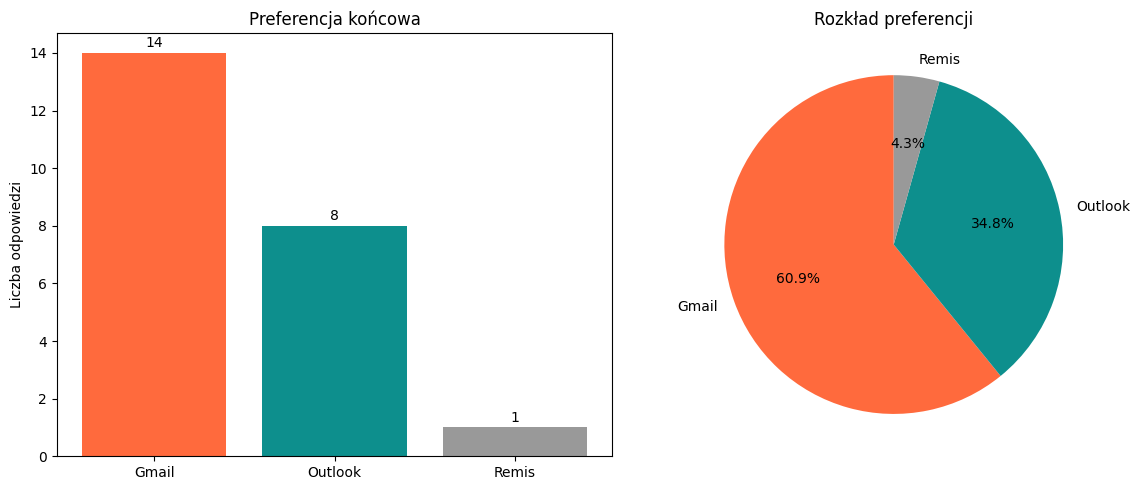

In [7]:
pref_counts = df['overall_preference'].value_counts()
labels_map = {'gmail': 'Gmail', 'outlook': 'Outlook', 'remis': 'Remis'}
pref_counts.index = [labels_map.get(i, i) for i in pref_counts.index]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Słupkowy
colors = ['#ff6a3d', '#0d8f8d', '#999999']
bars = ax1.bar(pref_counts.index, pref_counts.values, color=colors[:len(pref_counts)])
ax1.set_ylabel('Liczba odpowiedzi')
ax1.set_title('Preferencja końcowa')
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(int(bar.get_height())), ha='center', va='bottom')

# Kołowy
ax2.pie(pref_counts.values, labels=pref_counts.index, autopct='%1.1f%%',
        colors=colors[:len(pref_counts)], startangle=90)
ax2.set_title('Rozkład preferencji')

plt.tight_layout()
plt.show()

## 5. Liczba odpowiedzi w czasie

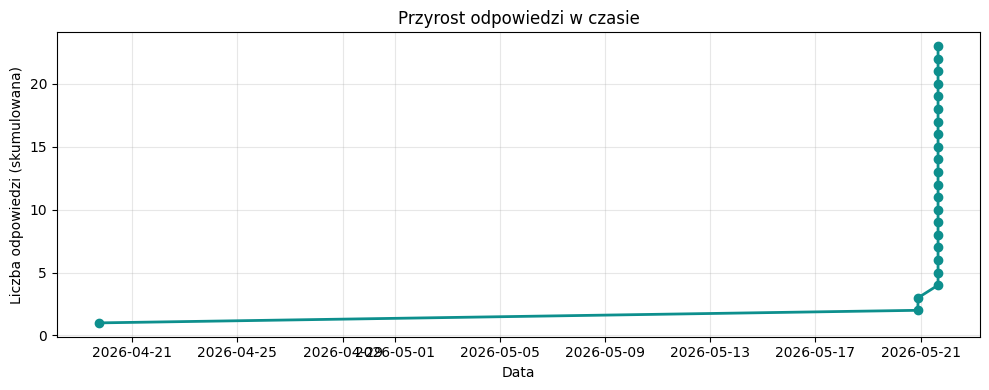

Łączna liczba odpowiedzi: 23


In [8]:
df_sorted = df.sort_values('created_at')
df_sorted['cumcount'] = range(1, len(df_sorted) + 1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_sorted['created_at'], df_sorted['cumcount'],
        marker='o', color='#0d8f8d', linewidth=2)
ax.set_xlabel('Data')
ax.set_ylabel('Liczba odpowiedzi (skumulowana)')
ax.set_title('Przyrost odpowiedzi w czasie')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Łączna liczba odpowiedzi: {len(df)}')

## 6. Komentarze uczestników

In [9]:
comments = df[df['overall_comment'].notna() & (df['overall_comment'] != '')][['created_at', 'participant_name', 'overall_comment']]
if len(comments):
    display(comments)
else:
    print('Brak komentarzy.')

,created_at,participant_name,overall_comment
0,2026-04-19 17:26:37.835460+00:00,test_user,Test insert z pliku.
4,2026-05-21 15:58:19.851469+00:00,piotrM,Outlook męczy mnie wolnym działaniem.
6,2026-05-21 15:58:19.975334+00:00,marek_z,Outlook lepszy do pracy biurowej.
7,2026-05-21 15:58:20.041840+00:00,zosia_x,Gmail jest bardziej intuicyjny.
8,2026-05-21 15:58:20.123296+00:00,tomek88,Gmail jest bardziej intuicyjny.
9,2026-05-21 15:58:20.183817+00:00,ewelina,Gmail wygrywa prostotą.
10,2026-05-21 15:58:20.242574+00:00,kuba_p,Outlook lepszy do pracy biurowej.
11,2026-05-21 15:58:20.300913+00:00,martyna_r,Po dłuższym użytkowaniu nie widzę dużej różnicy.
12,2026-05-21 15:58:20.357744+00:00,lukasz_b,Outlook lepszy do pracy biurowej.
15,2026-05-21 15:58:20.529662+00:00,ola_w,"Wolę Gmail, ale Outlook ma lepszy kalendarz."
